In [1]:
# ============================================================
#  环境配置
#  - Colab 用户：取消注释下方 Colab 区块
#  - 本地 Jupyter 用户：直接运行 Local 区块
# ============================================================

# ── Colab 环境（取消注释后运行） ──
# !pip install torch==2.6.0 -q
# !pip install matplotlib==3.9.4 numpy==1.26.4 -q
# !pip install invariant-point-attention==0.2.2 -q
!pip install torch torchvision matplotlib numpy -U -q
# ── 本地 Jupyter 环境 ──
# import subprocess, sys
# def _install(pkg):
#     subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

# _install('torch==2.6.0')
# _install('matplotlib==3.9.4')
# _install('numpy==1.26.4')
# _install('invariant-point-attention==0.2.2')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 109.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.3 which is incompatible.


# AlphaFold2 从零到一：源代码实现 vs 简洁实现

基于论文 *Highly accurate protein structure prediction with AlphaFold* (Jumper et al., 2021)，
用**坐标去噪任务**演示 AlphaFold2 的核心架构（Evoformer + IPA 结构模块）。

> AlphaFold2 由 DeepMind 开发，以原子级精度（< 1.5 Å）解决了困扰生物学界 50 年的蛋白质折叠问题，
> 在 CASP14 竞赛中远超所有对手，Hassabis 和 Jumper 因此获得 2024 年诺贝尔化学奖。

由于完整 AlphaFold2（48 层 Evoformer + 8 层 Structure Module）需要大量计算资源和生物数据库，
本 Notebook 构建**迷你版 AlphaFold2**，聚焦核心组件的原理验证：

| | 实现 A — 源代码实现 | 实现 B — 简洁实现 |
|---|---|---|
| 核心思路 | 逐组件手写 Evoformer + IPA | 使用 `invariant-point-attention` 库 + `nn.MultiheadAttention` |
| 代码量 | ~250 行 | ~60 行 |
| 适合场景 | 深入理解 Evoformer/IPA 原理、面试准备 | 快速原型、工程应用 |
| 任务 | 蛋白质骨架坐标去噪 | 同左 |

In [2]:
import math
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. 数据准备：合成蛋白质骨架

真实蛋白质数据需要 MSA 数据库搜索和 PDB 结构文件，不适合轻量演示。
我们生成**合成蛋白质骨架**：用参数化的 α-螺旋和 β-折叠几何构建 3D 坐标，
附带合成 MSA 特征和配对表示，用于验证架构的数据流和学习能力。

**任务**：给定加噪后的骨架坐标 + MSA/配对特征，恢复原始坐标（坐标去噪）。
这模拟了 AlphaFold2 结构模块的核心行为——从初始"原子云"迭代精修到精确结构。

In [3]:
# ── 超参数（两种实现共用，集中管理） ──
SEQ_LEN      = 16      # 残基数量（论文数百~数千，此处缩小）
NUM_SEQ      = 8       # MSA 中的序列数
D_MODEL      = 32      # 单序列/MSA 特征维度（论文 256/384）
D_PAIR       = 32      # 配对表示维度（论文 128）
NUM_HEADS    = 4       # 注意力头数
HEAD_DIM     = D_MODEL // NUM_HEADS  # 8
D_FF         = 64      # FFN 隐藏维度
NUM_EVO      = 2       # Evoformer 层数（论文 48）
NUM_STRUCT   = 2       # 结构模块迭代次数（论文 8，共享权重）
DROPOUT      = 0.0     # 小数据集关闭 Dropout
LR           = 3e-3
NUM_EPOCHS   = 80
BATCH_SIZE   = 32
NOISE_STD    = 2.0     # 坐标噪声标准差（Å）
NUM_SAMPLES  = 800     # 训练样本数
NUM_TEST     = 200     # 测试样本数

In [4]:
def generate_helix(L, noise=0.1):
    """生成 α-螺旋骨架 Cα 坐标 (L, 3)
    α-螺旋参数：每圈 3.6 个残基，螺距 5.4 Å，半径 2.3 Å"""
    t = torch.arange(L, dtype=torch.float32)
    x = 2.3 * torch.cos(2 * math.pi * t / 3.6)
    y = 2.3 * torch.sin(2 * math.pi * t / 3.6)
    z = 1.5 * t  # 沿 z 轴上升，间距 ~1.5 Å
    coords = torch.stack([x, y, z], dim=-1)  # (L, 3)
    coords += torch.randn_like(coords) * noise  # 轻微扰动增加多样性
    return coords

def generate_sheet(L, noise=0.1):
    """生成简化 β-折叠骨架坐标 (L, 3)
    交替折叠的锯齿形结构"""
    t = torch.arange(L, dtype=torch.float32)
    x = 3.5 * t  # 沿 x 轴延伸，Cα间距 ~3.5 Å
    y = 1.2 * (t % 2 == 0).float() - 0.6  # 锯齿形 y 坐标
    z = torch.zeros(L)
    coords = torch.stack([x, y, z], dim=-1)
    coords += torch.randn_like(coords) * noise
    return coords

class ProteinDataset(Dataset):
    """合成蛋白质骨架数据集
    每个样本包含：
    - clean_coords: 原始坐标 (L, 3)
    - noisy_coords: 加噪坐标 (L, 3)
    - msa_feat:     合成 MSA 特征 (S, L, D_MODEL)
    - pair_feat:    合成配对表示 (L, L, D_PAIR)
    """
    def __init__(self, n_samples, seq_len, num_seq, d_model, d_pair, noise_std):
        self.data = []
        for i in range(n_samples):
            # 随机选择螺旋或折叠，并施加随机旋转
            if i % 2 == 0:
                coords = generate_helix(seq_len, noise=0.2)
            else:
                coords = generate_sheet(seq_len, noise=0.2)

            # 随机旋转（SO(3)增强）
            theta = torch.rand(1).item() * 2 * math.pi
            R = torch.tensor([
                [math.cos(theta), -math.sin(theta), 0],
                [math.sin(theta),  math.cos(theta), 0],
                [0,                0,                1]
            ], dtype=torch.float32)
            coords = coords @ R.T

            # 中心化
            coords = coords - coords.mean(dim=0, keepdim=True)

            # 加噪
            noise = torch.randn_like(coords) * noise_std
            noisy = coords + noise

            # 合成 MSA 特征：基于坐标的距离信息编码 + 随机扰动
            single = torch.randn(seq_len, d_model) * 0.1
            # 将坐标信息注入前 3 维
            single[:, :3] = coords / 10.0
            msa = single.unsqueeze(0).expand(num_seq, -1, -1).clone()
            msa += torch.randn(num_seq, seq_len, d_model) * 0.05  # MSA 多样性

            # 合成配对表示：基于残基间距离
            dist = torch.cdist(coords, coords)  # (L, L)
            pair = torch.randn(seq_len, seq_len, d_pair) * 0.1
            pair[:, :, 0] = dist / 20.0  # 距离信息注入第 0 维
            # 相对位置编码注入
            rel_pos = torch.arange(seq_len).unsqueeze(1) - torch.arange(seq_len).unsqueeze(0)
            pair[:, :, 1] = rel_pos.float() / seq_len

            self.data.append((coords, noisy, msa, pair))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

# 创建数据集
train_set = ProteinDataset(NUM_SAMPLES, SEQ_LEN, NUM_SEQ, D_MODEL, D_PAIR, NOISE_STD)
test_set  = ProteinDataset(NUM_TEST, SEQ_LEN, NUM_SEQ, D_MODEL, D_PAIR, NOISE_STD)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
test_loader  = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)
print(f'训练集: {len(train_set)} 样本, {len(train_loader)} 批次')
print(f'测试集: {len(test_set)} 样本')

训练集: 800 样本, 25 批次
测试集: 200 样本


原始坐标:   torch.Size([16, 3])
加噪坐标:   torch.Size([16, 3])
MSA 特征:   torch.Size([8, 16, 32])
配对表示:   torch.Size([16, 16, 32])


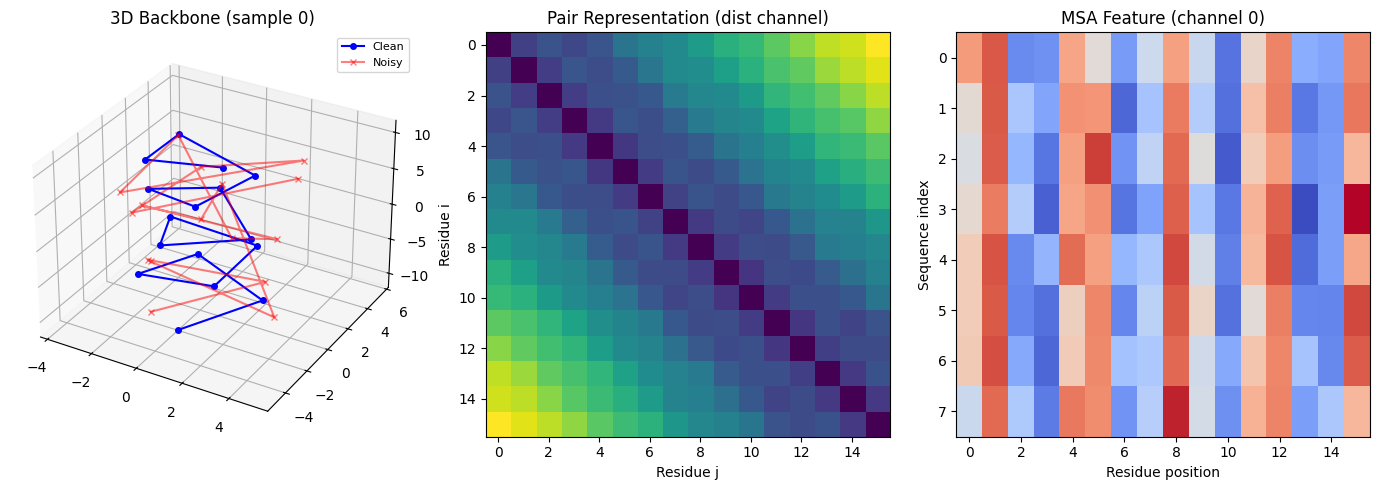

In [5]:
# ── 验证数据形状 + 可视化 ──
clean, noisy, msa, pair = train_set[0]
print(f'原始坐标:   {clean.shape}')   # (16, 3)
print(f'加噪坐标:   {noisy.shape}')   # (16, 3)
print(f'MSA 特征:   {msa.shape}')     # (8, 16, 32)
print(f'配对表示:   {pair.shape}')     # (16, 16, 32)

fig = plt.figure(figsize=(14, 5))
# 3D 骨架对比
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot(*clean.T.numpy(), 'b-o', markersize=4, label='Clean')
ax1.plot(*noisy.T.numpy(), 'r-x', markersize=4, alpha=0.5, label='Noisy')
ax1.set_title('3D Backbone (sample 0)')
ax1.legend(fontsize=8)

ax2 = fig.add_subplot(132)
ax2.imshow(pair[:, :, 0].numpy(), cmap='viridis')
ax2.set_title('Pair Representation (dist channel)')
ax2.set_xlabel('Residue j')
ax2.set_ylabel('Residue i')

ax3 = fig.add_subplot(133)
ax3.imshow(msa[:, :, 0].numpy(), cmap='coolwarm', aspect='auto')
ax3.set_title('MSA Feature (channel 0)')
ax3.set_xlabel('Residue position')
ax3.set_ylabel('Sequence index')

plt.tight_layout()
plt.show()

## 2. 共享组件

训练/评估函数与 3D 刚体变换工具，两种实现共用。

In [6]:
def init_identity_rotations(batch, length):
    """初始化单位旋转矩阵 (B, L, 3, 3)"""
    R = torch.eye(3).unsqueeze(0).unsqueeze(0)  # (1, 1, 3, 3)
    return R.expand(batch, length, -1, -1).clone()

def init_zero_translations(batch, length):
    """初始化零平移向量 (B, L, 3)"""
    return torch.zeros(batch, length, 3)

def compute_rmsd(pred, target):
    """计算 RMSD (Root Mean Square Deviation)
    pred, target: (B, L, 3)"""
    diff = pred - target  # (B, L, 3)
    return torch.sqrt((diff ** 2).sum(-1).mean(-1))  # (B,)

def plot_results(train_losses, test_rmsds, title='Training'):
    """绘制损失曲线和 RMSD 曲线"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses)
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss (MSE)')
    ax1.set_title(f'{title} — Loss')
    ax1.grid(True, alpha=0.3)

    ax2.plot(test_rmsds)
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('RMSD (Å)')
    ax2.set_title(f'{title} — Test RMSD')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def train_model(model, train_loader, test_loader, num_epochs=NUM_EPOCHS, lr=LR):
    """通用训练循环（两种实现共用）
    模型接口：model(noisy_coords, msa_feat, pair_feat) -> pred_coords (B, L, 3)
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    train_losses, test_rmsds = [], []

    for epoch in range(num_epochs):
        model.train()
        total_loss, n_batch = 0.0, 0
        for clean, noisy, msa, pair in train_loader:
            clean = clean.to(device)  # (B, L, 3)
            noisy = noisy.to(device)  # (B, L, 3)
            msa   = msa.to(device)    # (B, S, L, D_MODEL)
            pair  = pair.to(device)   # (B, L, L, D_PAIR)

            pred = model(noisy, msa, pair)  # (B, L, 3)
            loss = F.mse_loss(pred, clean)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()
            n_batch += 1

        scheduler.step()
        avg_loss = total_loss / n_batch
        train_losses.append(avg_loss)

        # ── 评估 ──
        model.eval()
        rmsds = []
        with torch.no_grad():
            for clean, noisy, msa, pair in test_loader:
                clean = clean.to(device)
                noisy = noisy.to(device)
                msa   = msa.to(device)
                pair  = pair.to(device)
                pred = model(noisy, msa, pair)
                rmsds.append(compute_rmsd(pred, clean).mean().item())
        avg_rmsd = np.mean(rmsds)
        test_rmsds.append(avg_rmsd)

        if (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1:3d}/{num_epochs}]  Loss: {avg_loss:.4f}  RMSD: {avg_rmsd:.3f} Å')

    return train_losses, test_rmsds

---

## 3. 实现 A — 源代码实现

逐组件手写 AlphaFold2 的核心模块，包含公式推导和维度注释。
组件顺序遵循模型数据流：MSA 注意力 → 配对表示更新 → Evoformer 组装 → IPA → 结构模块。

### 3.1 Row-wise Gated Self-Attention with Pair Bias（行注意力）

Evoformer 处理 MSA 表示的核心模块。对每一行（即每条同源序列）执行自注意力，
同时将配对表示 $z_{ij}$ 作为**注意力偏置**注入，让几何信息引导序列特征的更新。

$$a_{sij}^h = \text{softmax}_j \left( \frac{1}{\sqrt{d_k}} \mathbf{q}_{si}^{h\top} \mathbf{k}_{sj}^h + b_{ij}^h \right)$$

$$\mathbf{g}_{si}^h = \sigma(\text{Linear}(\mathbf{m}_{si})) \quad \text{(门控信号，控制信息流通量)}$$

$$\mathbf{o}_{si}^h = \mathbf{g}_{si}^h \odot \sum_j a_{sij}^h \mathbf{v}_{sj}^h$$

- **Pair Bias** $b_{ij}^h$：从配对表示线性投影得到，提供 "残基 $i$ 和 $j$ 的空间关系提示"
- **Gating** $\mathbf{g}$：Sigmoid 门控让模型自适应地控制每个位置的信息更新强度
- 输入: MSA $(B, S, L, C)$ + Pair $(B, L, L, C')$ → 输出: 更新后的 MSA $(B, S, L, C)$

In [7]:
class RowAttentionWithPairBias(nn.Module):
    """行注意力 + 配对偏置 + 门控（Algorithm 7）"""

    def __init__(self, d_model, d_pair, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.scale = self.head_dim ** -0.5

        self.norm = nn.LayerNorm(d_model)
        self.to_qkv = nn.Linear(d_model, d_model * 3, bias=False)
        self.to_gate = nn.Linear(d_model, d_model)    # 门控投影
        self.to_bias = nn.Linear(d_pair, num_heads, bias=False)  # 配对偏置
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, msa, pair):
        # msa:  (B, S, L, C)
        # pair: (B, L, L, C')
        B, S, L, C = msa.shape
        h, d = self.num_heads, self.head_dim

        x = self.norm(msa)                                   # (B, S, L, C)

        # QKV 投影
        qkv = self.to_qkv(x).reshape(B, S, L, 3, h, d)     # (B, S, L, 3, h, d)
        q, k, v = qkv.unbind(dim=3)                         # 各 (B, S, L, h, d)
        q = q.permute(0, 1, 3, 2, 4)                        # (B, S, h, L, d)
        k = k.permute(0, 1, 3, 2, 4)                        # (B, S, h, L, d)
        v = v.permute(0, 1, 3, 2, 4)                        # (B, S, h, L, d)

        # 注意力分数 + 配对偏置
        attn = (q @ k.transpose(-2, -1)) * self.scale       # (B, S, h, L, L)
        bias = self.to_bias(pair).permute(0, 3, 1, 2)       # (B, h, L, L)
        attn = attn + bias.unsqueeze(1)                      # 广播到所有序列
        attn = attn.softmax(dim=-1)                          # (B, S, h, L, L)

        # 加权聚合
        out = attn @ v                                       # (B, S, h, L, d)
        out = out.permute(0, 1, 3, 2, 4).reshape(B, S, L, C)  # (B, S, L, C)

        # 门控
        gate = torch.sigmoid(self.to_gate(x))                # (B, S, L, C)
        out = gate * out                                     # (B, S, L, C)

        return msa + self.proj(out)                          # 残差连接

### 3.2 Column-wise Gated Self-Attention（列注意力）

与行注意力类似，但沿 $S$ 维度（不同同源序列之间）进行信息混合。
列注意力**不使用配对偏置**，因为配对表示描述的是同一序列内残基间的关系。

列注意力捕捉：不同物种的蛋白质在同一位置上的**变异模式**（即共进化信号的直接来源）。

In [8]:
class ColumnAttention(nn.Module):
    """列注意力：沿序列维度（S）做自注意力，无配对偏置"""

    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.scale = self.head_dim ** -0.5

        self.norm = nn.LayerNorm(d_model)
        self.to_qkv = nn.Linear(d_model, d_model * 3, bias=False)
        self.to_gate = nn.Linear(d_model, d_model)
        self.proj = nn.Linear(d_model, d_model)

    def forward(self, msa):
        # msa: (B, S, L, C)
        B, S, L, C = msa.shape
        h, d = self.num_heads, self.head_dim

        # 转置 S 和 L，让注意力沿 S 维度计算
        x = msa.permute(0, 2, 1, 3)                         # (B, L, S, C)
        x = self.norm(x)

        qkv = self.to_qkv(x).reshape(B, L, S, 3, h, d)
        q, k, v = qkv.unbind(dim=3)                         # 各 (B, L, S, h, d)
        q = q.permute(0, 1, 3, 2, 4)                        # (B, L, h, S, d)
        k = k.permute(0, 1, 3, 2, 4)
        v = v.permute(0, 1, 3, 2, 4)

        attn = (q @ k.transpose(-2, -1)) * self.scale       # (B, L, h, S, S)
        attn = attn.softmax(dim=-1)

        out = attn @ v                                       # (B, L, h, S, d)
        out = out.permute(0, 1, 3, 2, 4).reshape(B, L, S, C)  # (B, L, S, C)

        gate = torch.sigmoid(self.to_gate(self.norm(msa.permute(0, 2, 1, 3))))
        out = gate * out
        out = self.proj(out).permute(0, 2, 1, 3)            # (B, S, L, C)

        return msa + out

### 3.3 Outer Product Mean（外积均值）

将 MSA 的一维序列特征 "升维" 为二维配对关系特征的专用模块。

1. **Mean（均值）**：沿 $S$ 维度平均，将数千条同源序列压缩为一条 "共识序列"
2. **Outer Product（外积）**：对任意位置对 $(i, j)$，计算特征向量的外积 $\mathbf{m}_i \otimes \mathbf{m}_j$

$$\text{OPM}(m)_{ij} = \text{Linear}\left(\frac{1}{S} \sum_s \text{Linear}(m_{si}) \otimes \text{Linear}(m_{sj})\right)$$

外积矩阵编码了 "哪些氨基酸倾向于协同变化" → "哪些氨基酸在空间上可能相互接触"。

In [9]:
class OuterProductMean(nn.Module):
    """外积均值：MSA (S,L,C) → 配对表示更新 (L,L,C')"""

    def __init__(self, d_model, d_pair, c=16):
        super().__init__()
        self.norm = nn.LayerNorm(d_model)
        self.proj_a = nn.Linear(d_model, c)     # 投影到低维 c
        self.proj_b = nn.Linear(d_model, c)
        self.out = nn.Linear(c * c, d_pair)     # 外积展平后投影回 d_pair

    def forward(self, msa, pair):
        # msa: (B, S, L, C), pair: (B, L, L, C')
        x = self.norm(msa)                       # (B, S, L, C)
        a = self.proj_a(x)                       # (B, S, L, c)
        b = self.proj_b(x)                       # (B, S, L, c)

        # 外积: a_i ⊗ b_j，然后沿 S 维度取平均
        # a: (B, S, L, c) → (B, S, L, 1, c, 1)
        # b: (B, S, L, c) → (B, S, 1, L, 1, c)
        outer = torch.einsum('bsic,bsjd->bijcd', a, b)  # (B, L, L, c, c)
        outer = outer / msa.shape[1]                      # 除以 S（均值）
        B, L1, L2, c1, c2 = outer.shape
        outer = outer.reshape(B, L1, L2, c1 * c2)       # (B, L, L, c*c)

        return pair + self.out(outer)                     # 残差更新配对表示

### 3.4 Triangle Self-Attention（三角自注意力）

AlphaFold2 的几何推理模块。将**边**（而非节点）作为处理对象，
从固定 "起始节点" 视角聚合三角关系信息。

对于起始节点 $i$，将所有边 $(i, 1), (i, 2), \ldots, (i, L)$ 组成一个序列，
在这个 "边序列" 上做自注意力。Query 来自边 $ij$，Key/Value 来自边 $ik$，
更新后的信息反映了 "从 $i$ 的视角看，$j$ 和 $k$ 的三角一致性"。

$$\text{TriAttn}(z)_{ij} = \sum_k \text{softmax}_k(q_{ij}^T k_{ik} / \sqrt{d_k} + b_{ik}) \cdot v_{ik}$$

In [10]:
class TriangleAttention(nn.Module):
    """三角自注意力（Around Starting Node）
    对配对表示的每一行（固定起始节点 i）做自注意力"""

    def __init__(self, d_pair, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_pair // num_heads
        self.scale = self.head_dim ** -0.5

        self.norm = nn.LayerNorm(d_pair)
        self.to_qkv = nn.Linear(d_pair, d_pair * 3, bias=False)
        self.to_bias = nn.Linear(d_pair, num_heads, bias=False)
        self.to_gate = nn.Linear(d_pair, d_pair)
        self.proj = nn.Linear(d_pair, d_pair)

    def forward(self, pair):
        # pair: (B, L, L, C')
        B, L, _, C = pair.shape
        h, d = self.num_heads, self.head_dim

        x = self.norm(pair)                                  # (B, L, L, C')

        qkv = self.to_qkv(x).reshape(B, L, L, 3, h, d)
        q, k, v = qkv.unbind(dim=3)                         # 各 (B, L, L, h, d)

        # 对每一行 i，边序列 (i,1)...(i,L) 做自注意力
        q = q.permute(0, 1, 3, 2, 4)                        # (B, L, h, L, d)
        k = k.permute(0, 1, 3, 2, 4)
        v = v.permute(0, 1, 3, 2, 4)

        attn = (q @ k.transpose(-2, -1)) * self.scale       # (B, L, h, L, L)
        bias = self.to_bias(x).permute(0, 3, 1, 2)          # (B, h, L, L)
        attn = attn + bias.unsqueeze(1)                      # 广播到所有起始节点
        attn = attn.softmax(dim=-1)

        out = attn @ v                                       # (B, L, h, L, d)
        out = out.permute(0, 1, 3, 2, 4).reshape(B, L, L, C)

        gate = torch.sigmoid(self.to_gate(x))
        out = gate * out

        return pair + self.proj(out)


class Transition(nn.Module):
    """前馈网络：升维 → ReLU → 降维"""

    def __init__(self, dim, expand=4):
        super().__init__()
        self.norm = nn.LayerNorm(dim)
        self.net = nn.Sequential(
            nn.Linear(dim, dim * expand),
            nn.ReLU(),
            nn.Linear(dim * expand, dim),
        )

    def forward(self, x):
        return x + self.net(self.norm(x))

### 3.5 Evoformer Block

组装上述模块形成完整的 Evoformer Block。每个 Block 同时更新 MSA 表示和配对表示：

1. **Row Attention** (+ Pair Bias)：MSA 行内信息混合，配对表示引导
2. **Column Attention**：MSA 列间信息混合（跨序列共进化）
3. **MSA Transition**：MSA 特征深度加工
4. **Outer Product Mean**：MSA → 配对表示更新
5. **Triangle Attention**：配对表示内的几何推理
6. **Pair Transition**：配对表示深度加工

AlphaFold2 使用 48 个这样的 Block 堆叠；我们使用 2 个验证原理。

In [11]:
class EvoformerBlock(nn.Module):
    """单个 Evoformer Block：同时更新 MSA 和 Pair 表示"""

    def __init__(self, d_model, d_pair, num_heads):
        super().__init__()
        # MSA 更新
        self.row_attn = RowAttentionWithPairBias(d_model, d_pair, num_heads)
        self.col_attn = ColumnAttention(d_model, num_heads)
        self.msa_transition = Transition(d_model)

        # Pair 更新
        self.outer_product_mean = OuterProductMean(d_model, d_pair)
        self.tri_attn = TriangleAttention(d_pair, num_heads)
        self.pair_transition = Transition(d_pair)

    def forward(self, msa, pair):
        # msa: (B, S, L, C), pair: (B, L, L, C')
        msa = self.row_attn(msa, pair)        # 行注意力 + 配对偏置
        msa = self.col_attn(msa)              # 列注意力
        msa = self.msa_transition(msa)        # MSA FFN

        pair = self.outer_product_mean(msa, pair)  # MSA → Pair 更新
        pair = self.tri_attn(pair)            # 三角注意力
        pair = self.pair_transition(pair)     # Pair FFN

        return msa, pair


class EvoformerStack(nn.Module):
    """Evoformer 编码器：N 个 Block 堆叠"""

    def __init__(self, d_model, d_pair, num_heads, num_layers):
        super().__init__()
        self.blocks = nn.ModuleList([
            EvoformerBlock(d_model, d_pair, num_heads) for _ in range(num_layers)
        ])

    def forward(self, msa, pair):
        for block in self.blocks:
            msa, pair = block(msa, pair)
        # 提取目标序列（第 0 行）作为单序列表示
        single = msa[:, 0]  # (B, L, C)
        return single, pair

### 3.6 Invariant Point Attention（不变点注意力，IPA）

IPA 是 AlphaFold2 结构模块的核心。它将三维空间中的原子坐标纳入注意力计算，
并保证计算结果对**全局刚体变换（旋转+平移）不变**。

核心思路：为每个残基建立**局部坐标系**，在局部坐标系中完成注意力计算，
从而摆脱对全局位置和姿态的依赖。

注意力权重混合三方面信息：
1. **标量通道**：单序列表示 $s_i, s_j$ 的相似度（"理论上的关系"）
2. **配对偏置**：$z_{ij}$ 中的几何蓝图信息
3. **点通道**：$i, j$ 在 3D 空间中的实际距离（"现在的位置"）

$$\alpha_{ij} = \text{softmax}_j \left( \frac{1}{\sqrt{d}} q_i^T k_j + b_{ij} - \gamma \|T_i(q_{pt}) - T_j(k_{pt})\|^2 \right)$$

其中 $T_i(\cdot)$ 将局部坐标点转换到全局坐标系：$T_i(p) = R_i \cdot p + t_i$

In [12]:
class InvariantPointAttentionScratch(nn.Module):
    """IPA 手写实现（简化版）"""

    def __init__(self, d_model, d_pair, num_heads, num_point_qk=4):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        self.num_point_qk = num_point_qk
        self.scale = self.head_dim ** -0.5

        # 标量通道
        self.to_q = nn.Linear(d_model, d_model, bias=False)
        self.to_k = nn.Linear(d_model, d_model, bias=False)
        self.to_v = nn.Linear(d_model, d_model, bias=False)

        # 点通道：每个头生成 num_point_qk 个 3D 查询/键点
        self.to_q_pts = nn.Linear(d_model, num_heads * num_point_qk * 3)
        self.to_k_pts = nn.Linear(d_model, num_heads * num_point_qk * 3)
        self.to_v_pts = nn.Linear(d_model, num_heads * num_point_qk * 3)

        # 配对偏置
        self.to_bias = nn.Linear(d_pair, num_heads, bias=False)

        # 可学习的权重系数 gamma（控制点通道的影响力）
        self.gamma = nn.Parameter(torch.ones(num_heads) * 0.5)

        # 输出投影：标量 + 配对 + 点值
        out_dim = d_model + num_heads * d_pair + num_heads * num_point_qk * 3
        self.proj = nn.Linear(out_dim, d_model)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, single, pair, rotations, translations):
        # single: (B, L, C), pair: (B, L, L, C')
        # rotations: (B, L, 3, 3), translations: (B, L, 3)
        B, L, C = single.shape
        h, d = self.num_heads, self.head_dim
        n_pts = self.num_point_qk

        x = self.norm(single)

        # ── 标量通道 ──
        q = self.to_q(x).reshape(B, L, h, d).permute(0, 2, 1, 3)  # (B, h, L, d)
        k = self.to_k(x).reshape(B, L, h, d).permute(0, 2, 1, 3)
        v = self.to_v(x).reshape(B, L, h, d).permute(0, 2, 1, 3)

        scalar_attn = (q @ k.transpose(-2, -1)) * self.scale       # (B, h, L, L)

        # ── 配对偏置 ──
        pair_bias = self.to_bias(pair).permute(0, 3, 1, 2)         # (B, h, L, L)

        # ── 点通道 ──
        q_pts = self.to_q_pts(x).reshape(B, L, h, n_pts, 3)       # (B, L, h, n_pts, 3)
        k_pts = self.to_k_pts(x).reshape(B, L, h, n_pts, 3)
        v_pts = self.to_v_pts(x).reshape(B, L, h, n_pts, 3)

        # T_i(p) = R_i @ p + t_i — 局部点变换到全局坐标系
        R = rotations.unsqueeze(2).unsqueeze(3)                     # (B, L, 1, 1, 3, 3)
        t = translations.unsqueeze(2).unsqueeze(3)                  # (B, L, 1, 1, 3)
        R_exp = R.expand(-1, -1, h, n_pts, -1, -1)

        q_pts_g = torch.einsum('blhnij,blhnj->blhni', R_exp, q_pts) + t  # (B, L, h, n_pts, 3)
        k_pts_g = torch.einsum('blhnij,blhnj->blhni', R_exp, k_pts) + t
        v_pts_g = torch.einsum('blhnij,blhnj->blhni', R_exp, v_pts) + t

        # 点距离注意力: -gamma * sum_p ||q_pt_i^p - k_pt_j^p||^2
        q_p = q_pts_g.permute(0, 2, 3, 1, 4)                       # (B, h, n_pts, L, 3)
        k_p = k_pts_g.permute(0, 2, 3, 1, 4)

        pt_diff = q_p.unsqueeze(-2) - k_p.unsqueeze(-3)            # (B, h, n_pts, L, L, 3)
        pt_dist_sq = (pt_diff ** 2).sum(-1).sum(2)                  # (B, h, L, L) 对 n_pts 求和
        gamma = F.softplus(self.gamma).reshape(1, h, 1, 1)
        pt_attn = -gamma * pt_dist_sq                               # (B, h, L, L)

        # ── 合并注意力 ──
        attn = (scalar_attn + pair_bias + pt_attn).softmax(dim=-1)  # (B, h, L, L)

        # ── 聚合 ──
        # 标量值
        scalar_out = (attn @ v).permute(0, 2, 1, 3).reshape(B, L, C)  # (B, L, C)

        # 配对值
        pair_out = torch.einsum('bhij,bijc->bihc', attn, pair)     # (B, L, h, C')
        pair_out = pair_out.reshape(B, L, h * pair.shape[-1])

        # 点值聚合: 对每个头每个点，用 attn 权重聚合 v_pts_global
        v_p = v_pts_g.permute(0, 2, 3, 1, 4)                       # (B, h, n_pts, L, 3)
        # attn: (B, h, L, L), v_p[:,:,p]: (B, h, L, 3) — 对 L(key) 维加权求和
        pt_out = torch.zeros(B, h, n_pts, L, 3, device=single.device)
        for p in range(n_pts):
            pt_out[:, :, p] = torch.einsum('bhij,bhjd->bhid', attn, v_p[:, :, p])
        pt_out = pt_out.permute(0, 3, 1, 2, 4).reshape(B, L, h * n_pts * 3)

        out = torch.cat([scalar_out, pair_out, pt_out], dim=-1)
        return single + self.proj(out)

### 3.7 Structure Module（结构模块）

结构模块是 AlphaFold2 的解码器，由共享参数的 Block 组成（类似 RNN）：

1. **初始化**：所有残基在原点 $(0,0,0)$，旋转为单位矩阵
2. **IPA**：根据单序列表示 + 配对蓝图 + 当前 3D 位置，计算更新方案
3. **预测平移**：从更新后的特征预测 $(\Delta x, \Delta y, \Delta z)$
4. **迭代精修**：重复 $N$ 次，结构逐步从 "原子云" 收敛到合理构象

### 训练 vs 推理的区别

| 阶段 | 行为 | 说明 |
|------|------|------|
| **训练** | 所有迭代步的预测都参与损失计算（辅助损失） | 加速收敛，防止后续步退化 |
| **推理** | 仅取最后一步的输出 | 最终预测即 3D 结构 |

In [13]:
class StructureModuleScratch(nn.Module):
    """结构模块：IPA + 坐标预测，共享权重迭代 N 次"""

    def __init__(self, d_model, d_pair, num_heads, num_iters):
        super().__init__()
        self.num_iters = num_iters

        # 共享权重的 IPA + Transition（所有迭代步共用）
        self.ipa = InvariantPointAttentionScratch(d_model, d_pair, num_heads)
        self.transition = Transition(d_model)

        # 坐标预测头
        self.to_coords = nn.Linear(d_model, 3)

    def forward(self, single, pair):
        # single: (B, L, C), pair: (B, L, L, C')
        B, L, _ = single.shape

        # 初始化：所有残基在原点
        rotations = init_identity_rotations(B, L).to(single.device)    # (B, L, 3, 3)
        translations = init_zero_translations(B, L).to(single.device)  # (B, L, 3)

        s = single  # 可更新的单序列表示

        for i in range(self.num_iters):
            # IPA 更新单序列表示
            s = self.ipa(s, pair, rotations, translations)   # (B, L, C)
            s = self.transition(s)

            # 预测坐标增量并累加
            delta = self.to_coords(s)                         # (B, L, 3)
            translations = translations + delta               # 累加平移

        return translations  # 最终 3D 坐标 (B, L, 3)

### 3.8 完整 Mini AlphaFold2 模型

组装所有组件：

$$\text{输入} \xrightarrow{\text{Evoformer}} (\text{single}, \text{pair}) \xrightarrow{\text{Structure Module}} \text{3D 坐标}$$

In [14]:
class MiniAlphaFold2(nn.Module):
    """迷你 AlphaFold2：Evoformer 编码器 + Structure Module 解码器"""

    def __init__(self, d_model, d_pair, num_heads, num_evo_layers, num_struct_iters):
        super().__init__()
        self.evoformer = EvoformerStack(d_model, d_pair, num_heads, num_evo_layers)
        self.structure = StructureModuleScratch(d_model, d_pair, num_heads, num_struct_iters)

    def forward(self, noisy_coords, msa, pair):
        # noisy_coords: (B, L, 3) — 加噪坐标（本任务中作为额外输入）
        # msa:  (B, S, L, C)
        # pair: (B, L, L, C')

        # 将加噪坐标信息注入 MSA 的前 3 维
        msa = msa.clone()
        msa[:, 0, :, :3] = msa[:, 0, :, :3] + noisy_coords / 10.0

        # Evoformer 编码
        single, pair = self.evoformer(msa, pair)  # (B,L,C), (B,L,L,C')

        # Structure Module 解码
        pred_coords = self.structure(single, pair)  # (B, L, 3)
        return pred_coords

model_a = MiniAlphaFold2(
    D_MODEL, D_PAIR, NUM_HEADS, NUM_EVO, NUM_STRUCT
).to(device)
total_params = sum(p.numel() for p in model_a.parameters())
print(f'MiniAlphaFold2 (源代码实现) 参数量: {total_params:,}')

MiniAlphaFold2 (源代码实现) 参数量: 107,575


### 训练实现 A

In [15]:
losses_a, rmsds_a = train_model(model_a, train_loader, test_loader)

Epoch [ 20/80]  Loss: 0.1626  RMSD: 0.751 Å
Epoch [ 40/80]  Loss: 0.0695  RMSD: 0.456 Å
Epoch [ 60/80]  Loss: 0.0396  RMSD: 0.400 Å
Epoch [ 80/80]  Loss: 0.0313  RMSD: 0.373 Å


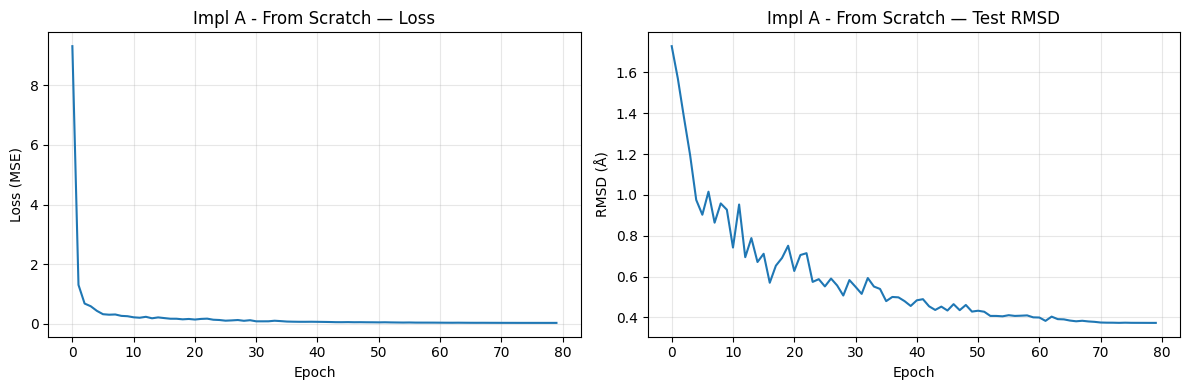

最终测试 RMSD: 0.373 Å


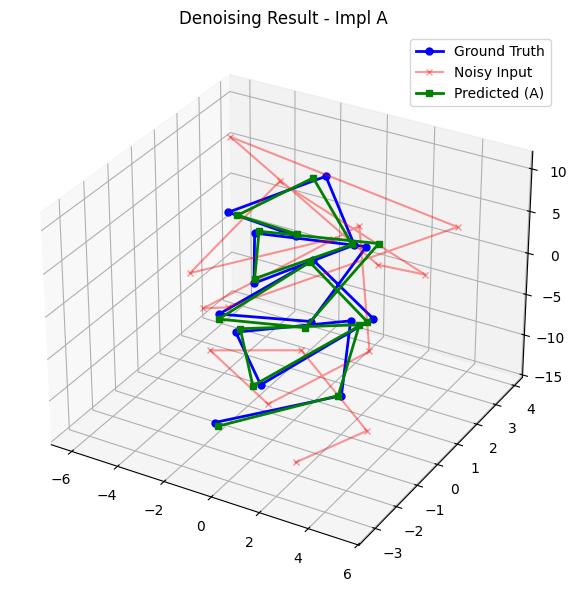

In [16]:
plot_results(losses_a, rmsds_a, title='Impl A - From Scratch')
print(f'最终测试 RMSD: {rmsds_a[-1]:.3f} Å')

# 可视化去噪效果
model_a.eval()
clean, noisy, msa, pair = test_set[0]
with torch.no_grad():
    pred = model_a(
        noisy.unsqueeze(0).to(device),
        msa.unsqueeze(0).to(device),
        pair.unsqueeze(0).to(device)
    )[0].cpu()

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(*clean.T.numpy(), 'b-o', markersize=5, label='Ground Truth', linewidth=2)
ax.plot(*noisy.T.numpy(), 'r-x', markersize=5, alpha=0.4, label='Noisy Input')
ax.plot(*pred.T.numpy(), 'g-s', markersize=5, label='Predicted (A)', linewidth=2)
ax.set_title('Denoising Result - Impl A')
ax.legend()
plt.tight_layout()
plt.show()

---

## 4. 实现 B — 简洁实现

使用 `invariant-point-attention` 库（lucidrains 实现）+ PyTorch 内置模块简化：

| 源代码实现 | 简洁实现 |
|---|---|
| `RowAttentionWithPairBias` | `nn.MultiheadAttention` + 手动 pair bias |
| `ColumnAttention` | `nn.MultiheadAttention` |
| `OuterProductMean` | 保留（无高层替代） |
| `TriangleAttention` | `nn.MultiheadAttention` (沿行) |
| `InvariantPointAttentionScratch` | `invariant_point_attention.IPABlock` |
| `StructureModuleScratch` | 基于 `IPABlock` 的精简版 |

In [18]:
# ===== 安装依赖（Colab）=====
import sys, subprocess, pkgutil

def pip_install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

# lucidrains 的 IPA 依赖一般还需要 einops
if pkgutil.find_loader("einops") is None:
    pip_install("einops")

# pip 包名是 invariant-point-attention，import 名是 invariant_point_attention
if pkgutil.find_loader("invariant_point_attention") is None:
    pip_install("invariant-point-attention")

from invariant_point_attention import InvariantPointAttention as IPALib

/tmp/ipykernel_296/3494018339.py:8: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("einops") is None:
/tmp/ipykernel_296/3494018339.py:12: DeprecationWarning: 'pkgutil.find_loader' is deprecated and slated for removal in Python 3.14; use importlib.util.find_spec() instead
  if pkgutil.find_loader("invariant_point_attention") is None:


In [19]:
from invariant_point_attention import InvariantPointAttention as IPALib

class ConciseEvoformerBlock(nn.Module):
    """简洁 Evoformer Block：用 nn.MultiheadAttention 替代手写注意力"""

    def __init__(self, d_model, d_pair, num_heads):
        super().__init__()
        # MSA 行注意力（用 nn.MultiheadAttention 简化，配对偏置省略）
        self.row_attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.row_norm = nn.LayerNorm(d_model)
        # MSA 列注意力
        self.col_attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)
        self.col_norm = nn.LayerNorm(d_model)
        # MSA FFN
        self.msa_ffn = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, d_model * 4),
            nn.ReLU(), nn.Linear(d_model * 4, d_model)
        )
        # Outer Product Mean (无高层替代，保留)
        self.opm = OuterProductMean(d_model, d_pair)
        # Pair FFN
        self.pair_ffn = nn.Sequential(
            nn.LayerNorm(d_pair), nn.Linear(d_pair, d_pair * 4),
            nn.ReLU(), nn.Linear(d_pair * 4, d_pair)
        )

    def forward(self, msa, pair):
        B, S, L, C = msa.shape
        # 行注意力：对每条序列
        m = msa.reshape(B * S, L, C)
        m_n = self.row_norm(m)
        m = m + self.row_attn(m_n, m_n, m_n, need_weights=False)[0]
        msa = m.reshape(B, S, L, C)

        # 列注意力：对每个位置
        m = msa.permute(0, 2, 1, 3).reshape(B * L, S, C)
        m_n = self.col_norm(m)
        m = m + self.col_attn(m_n, m_n, m_n, need_weights=False)[0]
        msa = m.reshape(B, L, S, C).permute(0, 2, 1, 3)

        msa = msa + self.msa_ffn(msa)
        pair = self.opm(msa, pair)
        pair = pair + self.pair_ffn(pair)
        return msa, pair


class MiniAlphaFold2Concise(nn.Module):
    """简洁版 Mini AlphaFold2：使用库 IPA + nn.MultiheadAttention"""

    def __init__(self, d_model, d_pair, num_heads, num_evo_layers, num_struct_iters):
        super().__init__()
        self.evo_blocks = nn.ModuleList([
            ConciseEvoformerBlock(d_model, d_pair, num_heads)
            for _ in range(num_evo_layers)
        ])
        self.num_struct_iters = num_struct_iters
        # 使用 lucidrains IPA 库
        self.ipa = IPALib(
            dim=d_model,
            heads=num_heads,
            scalar_key_dim=d_model // num_heads,
            scalar_value_dim=d_model // num_heads,
            point_key_dim=4,
            point_value_dim=4,
            require_pairwise_repr=False,  # 简化：不使用 pair repr
        )
        self.ipa_norm = nn.LayerNorm(d_model)
        self.ipa_ffn = nn.Sequential(
            nn.LayerNorm(d_model), nn.Linear(d_model, d_model * 4),
            nn.ReLU(), nn.Linear(d_model * 4, d_model)
        )
        self.to_coords = nn.Linear(d_model, 3)

    def forward(self, noisy_coords, msa, pair):
        B, L = noisy_coords.shape[:2]
        msa = msa.clone()
        msa[:, 0, :, :3] = msa[:, 0, :, :3] + noisy_coords / 10.0

        for block in self.evo_blocks:
            msa, pair = block(msa, pair)

        single = msa[:, 0]  # (B, L, C)

        # Structure module with library IPA
        translations = torch.zeros(B, L, 3, device=single.device)
        rotations = init_identity_rotations(B, L).to(single.device)
        mask = torch.ones(B, L, dtype=torch.bool, device=single.device)

        s = single
        for _ in range(self.num_struct_iters):
            s_n = self.ipa_norm(s)
            s = s + self.ipa(s_n, rotations=rotations, translations=translations, mask=mask)
            s = s + self.ipa_ffn(s)
            translations = translations + self.to_coords(s)

        return translations

model_b = MiniAlphaFold2Concise(
    D_MODEL, D_PAIR, NUM_HEADS, NUM_EVO, NUM_STRUCT
).to(device)
total_params_b = sum(p.numel() for p in model_b.parameters())
print(f'MiniAlphaFold2 (简洁实现) 参数量: {total_params_b:,}')

MiniAlphaFold2 (简洁实现) 参数量: 88,871


In [20]:
losses_b, rmsds_b = train_model(model_b, train_loader, test_loader)

/usr/local/lib/python3.12/dist-packages/invariant_point_attention/invariant_point_attention.py:156: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with disable_tf32(), autocast(enabled = False):


Epoch [ 20/80]  Loss: 0.0901  RMSD: 0.542 Å
Epoch [ 40/80]  Loss: 0.0624  RMSD: 0.474 Å
Epoch [ 60/80]  Loss: 0.0351  RMSD: 0.361 Å
Epoch [ 80/80]  Loss: 0.0312  RMSD: 0.352 Å


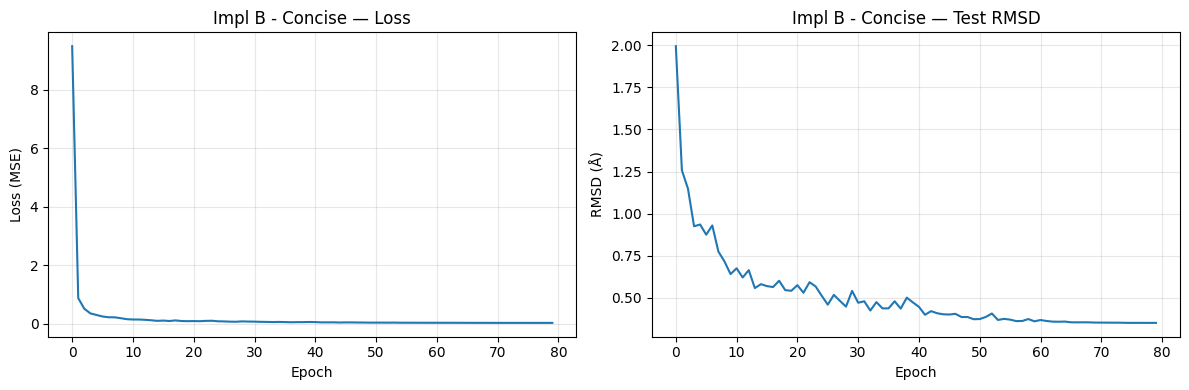

最终测试 RMSD: 0.352 Å


In [21]:
plot_results(losses_b, rmsds_b, title='Impl B - Concise')
print(f'最终测试 RMSD: {rmsds_b[-1]:.3f} Å')

---

## 5. 结果对比

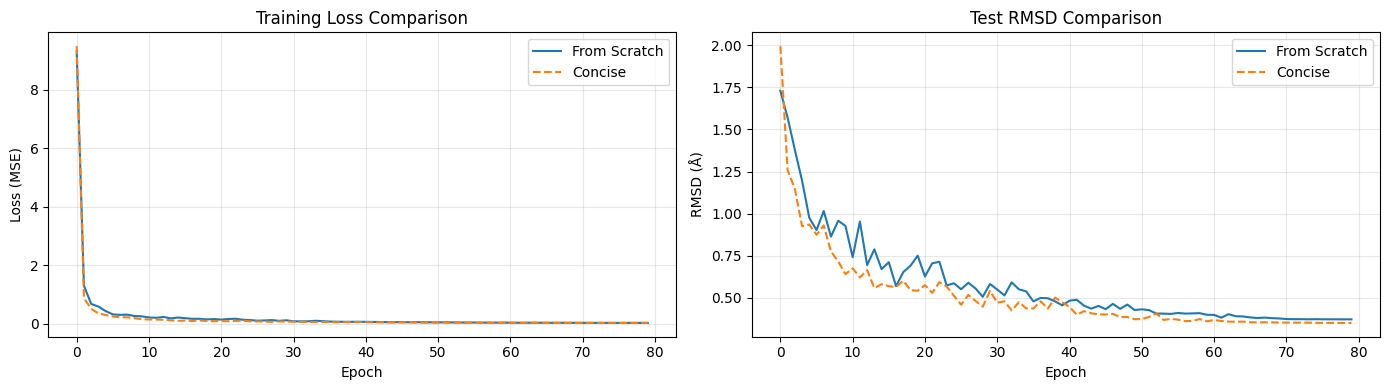

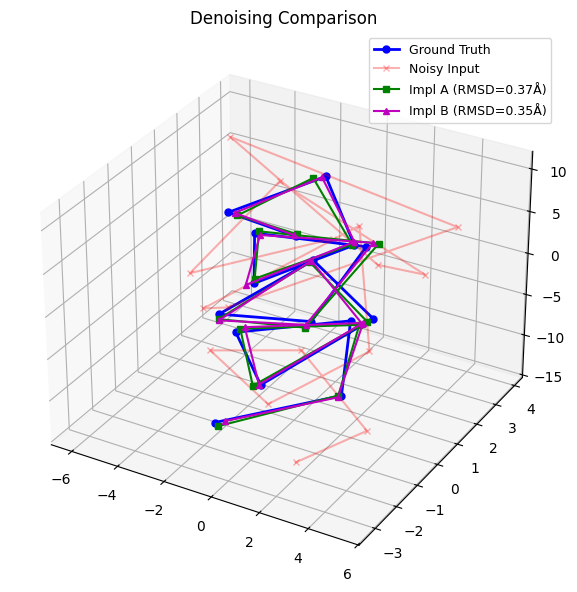

实现 A 最终 RMSD: 0.373 Å
实现 B 最终 RMSD: 0.352 Å
两种实现核心逻辑等价，结果差异来自：
  1. 实现 A 包含完整配对偏置和门控机制
  2. 实现 B 的简洁 IPA 省略了 pairwise repr，由 Evoformer 间接补偿


In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(losses_a, label='From Scratch')
ax1.plot(losses_b, '--', label='Concise')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training Loss Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(rmsds_a, label='From Scratch')
ax2.plot(rmsds_b, '--', label='Concise')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('RMSD (Å)')
ax2.set_title('Test RMSD Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── 3D 去噪效果对比 ──
model_a.eval()
model_b.eval()
clean, noisy, msa, pair = test_set[0]
with torch.no_grad():
    n, m, p = [x.unsqueeze(0).to(device) for x in [noisy, msa, pair]]
    pred_a = model_a(n, m, p)[0].cpu()
    pred_b = model_b(n, m, p)[0].cpu()

fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(*clean.T.numpy(), 'b-o', markersize=5, label='Ground Truth', linewidth=2)
ax.plot(*noisy.T.numpy(), 'r-x', markersize=5, alpha=0.3, label='Noisy Input')
ax.plot(*pred_a.T.numpy(), 'g-s', markersize=5, label=f'Impl A (RMSD={rmsds_a[-1]:.2f}Å)')
ax.plot(*pred_b.T.numpy(), 'm-^', markersize=5, label=f'Impl B (RMSD={rmsds_b[-1]:.2f}Å)')
ax.set_title('Denoising Comparison')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'实现 A 最终 RMSD: {rmsds_a[-1]:.3f} Å')
print(f'实现 B 最终 RMSD: {rmsds_b[-1]:.3f} Å')
print('两种实现核心逻辑等价，结果差异来自：')
print('  1. 实现 A 包含完整配对偏置和门控机制')
print('  2. 实现 B 的简洁 IPA 省略了 pairwise repr，由 Evoformer 间接补偿')

---

## 附录 A：AlphaFold3 — 架构演进

AlphaFold3（2024 年 5 月发布）在 AlphaFold2 基础上进行了重大架构改进，
Hassabis 和 Jumper 因 AlphaFold 系列工作获得 2024 年诺贝尔化学奖。

### 核心架构变化

| 特性 | AlphaFold2 | AlphaFold3 |
|------|-----------|-----------|
| **核心编码器** | Evoformer（48 层，含 MSA） | Pairformer（48 层，无 MSA）+ 4 层 MSA Module |
| **MSA 处理** | 深度集成到 Evoformer | 最小化（仅 4 层独立处理） |
| **结构预测** | Structure Module（SE(3)-等变，IPA） | Diffusion Module（非等变，生成式） |
| **输出形式** | 残基坐标 + 扭转角 | 原子级坐标（直接预测） |
| **适用范围** | 蛋白质 | 蛋白质 + DNA/RNA + 配体 + 离子 |
| **等变性** | 严格保证（IPA 设计核心） | 不强制（靠数据增强学习） |

### 关键创新

1. **Pairformer**：移除 MSA 与 Pair 的深度交互，仅保留 Single 和 Pair 表示的更新，
   更简洁高效。Outer Product Mean 不再出现在主循环中。

2. **Diffusion Module**：用条件扩散模型替代 IPA 结构模块。从随机原子云出发，
   在 Pairformer 输出的条件引导下迭代去噪，生成最终 3D 结构。
   这与我们 notebook 中的 "坐标去噪" 任务高度类似——AlphaFold3 本质上就是一个
   条件去噪过程。

3. **全原子预测**：不再依赖残基级别的刚体变换（旋转+平移），而是直接预测每个原子的坐标。

### 开源替代

| 项目 | 许可证 | 安装 |
|------|--------|------|
| Boltz-1/2 | MIT | `pip install boltz` |
| Protenix (ByteDance) | Apache 2.0 | GitHub |
| OpenFold-3 | MIT | GitHub |
| alphafold3-pytorch (lucidrains) | MIT | `pip install alphafold3-pytorch` |

---

## 附录 B：面试拓展

### 高频面试题

**Q1: AlphaFold2 为什么能解决蛋白质折叠问题？核心创新是什么？**

AlphaFold2 将蛋白质折叠重新定义为**进化信息 + 几何空间上的图推理问题**，
核心创新包括：
- **Evoformer**：同时处理 MSA 和配对表示两个二维输入，通过行/列注意力 + 外积均值 + 三角注意力提取氨基酸间的深层关系
- **IPA**：保证 SE(3) 不变性的注意力机制，将 3D 几何推理融入 Transformer
- **迭代精修**：结构模块共享权重循环 8 次，从原子云逐步折叠
- **端到端训练**：从序列直接到 3D 坐标，无需传统的能量函数优化

**Q2: MSA（多序列比对）在 AlphaFold2 中的作用？去掉会怎样？**

MSA 提供**进化信息**，是 AlphaFold2 最重要的输入特征之一：
- **保守性**：高度保守的位置对结构/功能至关重要
- **共进化**：两个位置协同变异 → 它们在空间上可能接近
- 消融实验表明去掉 MSA 后准确率下降约 **10 个百分点**
- AlphaFold3 大幅减少了 MSA 依赖（仅 4 层处理），说明其他信号可以部分补偿

**Q3: 配对表示（Pair Representation）存储什么信息？为什么是 $L \times L$？**

- 配对表示是一个 $(L, L, C')$ 的张量，描述任意两个残基 $i, j$ 之间的关系
- 位置 $(i, j)$ 存储：空间距离、相对朝向、共进化强度等几何蓝图信息
- $L \times L$ 结构天然适合建模**成对关系**，类似图的邻接矩阵
- 在 Evoformer 中通过外积均值从 MSA 注入，通过三角注意力在内部精修

**Q4: IPA 如何实现对刚体变换的不变性？为什么这很重要？**

实现机制：
1. 为每个残基 $i$ 建立**独立的局部坐标系**（基于主链原子）
2. 将其他残基 $j$ 的信息转换到 $i$ 的局部坐标系中
3. 在局部坐标系中完成注意力计算
4. 将局部更新指令翻译回全局坐标系

重要性：蛋白质的生物功能取决于**内部结构**而非全局姿态。将蛋白质平移 100Å
或旋转 90° 后，它的功能完全不变。IPA 保证模型理解这一物理事实，
避免对同一蛋白质的不同姿态产生不同预测。

**Q5: 三角注意力的设计动机是什么？**

蛋白质中三个残基 $i, j, k$ 的距离满足**三角不等式**：
$d(i,j) + d(j,k) \geq d(i,k)$。三角注意力让模型在更新边 $(i,j)$ 时，
同时考虑边 $(i,k)$ 和 $(k,j)$，确保预测的距离矩阵满足几何一致性。
这是 AlphaFold2 独有的创新，将图论中的三角约束融入注意力机制。

**Q6: AlphaFold2 的损失函数是什么？**

主要损失包括：
- **FAPE Loss**（Frame Aligned Point Error）：在每个残基的局部坐标系下计算坐标误差，保证 SE(3) 不变性
- **pLDDT 辅助损失**：预测每个残基的置信度分数
- **Distogram Loss**：预测残基间距离的概率分布
- **辅助迭代损失**：结构模块每一步的输出都参与损失计算

**Q7: AlphaFold2 的局限性？**

- 无法预测**全新折叠类型**：依赖 PDB 训练数据中已有的折叠模式
- **多构象问题**：只输出一个结构，无法建模蛋白质的动态柔性
- **多域蛋白**：域间相对取向预测不够准确
- **MSA 依赖**：某些蛋白质缺乏足够的同源序列（orphan proteins）
- **不是物理模拟**：不建模折叠动力学过程，只预测最终稳态结构

**Q8: AlphaFold2 vs AlphaFold3 vs ESMFold 如何选择？**

| 对比维度 | AlphaFold2 | AlphaFold3 | ESMFold |
|---------|-----------|-----------|---------|
| 输入 | 序列 + MSA + 模板 | 序列 + MSA（可选） | 仅序列 |
| 预测范围 | 蛋白质 | 蛋白质/DNA/RNA/配体 | 蛋白质 |
| 精度 | CASP14 最佳 | 优于 AF2 | 略低于 AF2 |
| 速度 | 慢（需 MSA 搜索） | 中等 | 快（无需 MSA） |
| 适用场景 | 高精度单蛋白 | 复合物/药物设计 | 快速筛选/大规模预测 |

### 延伸阅读与对比

| 对比维度 | AlphaFold2 | RoseTTAFold | ESMFold |
|---------|-----------|-------------|---------|
| 核心思想 | Evoformer + IPA | 三轨网络 | 蛋白质语言模型 |
| MSA 需求 | 必需 | 必需 | 不需要 |
| 创新点 | 三角注意力/IPA | 1D-2D-3D 信息交互 | 大规模预训练 |
| 复杂度 | 高（$O(L^2 S)$） | 中 | 低（$O(L^2)$）|

### 进阶探索方向

- **AlphaFold-Multimer**：预测蛋白质复合物（多链）
- **AlphaFold3 Diffusion**：将蛋白质结构生成建模为去噪扩散过程
- **ESM-2/ESMFold**：用蛋白质语言模型替代 MSA，大幅提速
- **蛋白质设计（Inverse Folding）**：给定 3D 结构，设计对应序列（如 ProteinMPNN）
- **分子动力学 + AI**：用 AlphaFold 预测初始结构，再用 MD 模拟动态行为